In [17]:
from src.utils.DataFolder import DataFolder
from src.ThetaSignal import ThetaSignal
from src.pipeline import emd_analysis

import numpy as np
import pandas as pd

import emd
import matplotlib.pyplot as plt

data_path = "/home/miranjo/phasic_tonic/data/processed"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"


fs = args.pop("fs", 2500)
f_theta = (args.pop("f_theta_lower", 4), args.pop("f_theta_upper", 12))
f_lowpass = args.pop("f_lowpass", 25)
n_seconds_filter = args.pop("n_seconds_filter", 0.5)
n_seconds_theta = args.pop("n_seconds_theta", 0.75)

threshold_kwargs = args.pop("threshold_kwargs", None)

In [2]:
remFolder = DataFolder(data_path)
print(remFolder)

DataFolder in '/home/miranjo/phasic_tonic/data/processed', contains 102 files.


In [5]:
remData = remFolder[3]
arrays = remData["data"]
metadata = remData["metadata"]

sig = ThetaSignal(arrays[0], fs)
sig.filter('bandpass', f_theta, n_seconds_theta)
sig.segment_cycles()

Phasic periods in the bandpass signal: 47
Periods: 
 [(106769, 108987), (125289, 127831), (171562, 174662), (267133, 272945)]
Tonic periods in the bandpass signal: 865
Periods: 
 [(333, 125289), (127831, 171562), (174662, 267133), (269655, 269888), (272945, 305444)]


In [10]:

# Compute frequency statistics
IP, IF, IA = emd.spectra.frequency_transform(sig.filtered, sig.sampling_rate, 'nht')

In [11]:
freq_edges, freq_centres = emd.spectra.define_hist_bins(1, 45, 8, 'log')

# We round the values to 3dp for easier visualisation
print('Bin Edges:   {0}'.format(np.round(freq_edges, 3)))
print('Bin Centres: {0}'.format(np.round(freq_centres, 3)))

Bin Edges:   [ 1.     1.609  2.59   4.168  6.708 10.796 17.374 27.962 45.   ]
Bin Centres: [ 1.305  2.1    3.379  5.438  8.752 14.085 22.668 36.481]


In [12]:
freq_edges, freq_centres = emd.spectra.define_hist_bins(1, 50, 8, 'log')
f, spectrum = emd.spectra.hilberthuang(IF, IA, freq_edges)

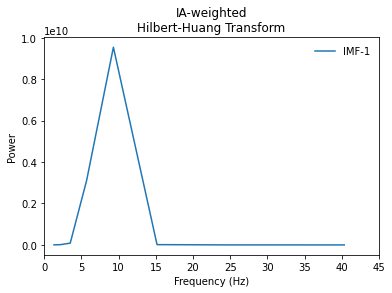

In [20]:
plt.plot(freq_centres, spectrum)
plt.xticks(np.arange(10)*5)
plt.xlim(0, 45)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('IA-weighted\nHilbert-Huang Transform')
plt.legend(['IMF-1', 'IMF-2', 'IMF-3', 'IMF-4', 'IMF-5'], frameon=False)